In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print("Google Drive mounted!")

Mounted at /content/drive
Google Drive mounted!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
import seaborn as sns
import os

INPUT_FILE = "/content/drive/MyDrive/insider_threat/data/anomaly_scores.csv"
CHART_DIR  = "/content/drive/MyDrive/insider_threat/charts"
os.makedirs(CHART_DIR, exist_ok=True)

sns.set_theme(style="darkgrid")
PALETTE = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}

print("Libraries loaded!")
print("Setup complete!")

Libraries loaded!
Setup complete!


In [3]:
print("Loading anomaly scores...")

df = pd.read_csv(INPUT_FILE)
print(f"Loaded {len(df)} users")
print(f"Risk levels: {df['risk_level'].value_counts().to_dict()}")
print("Done!")

Loading anomaly scores...
Loaded 500 users
Risk levels: {'Low': 484, 'High': 15, 'Medium': 1}
Done!


Generating risk score distribution...


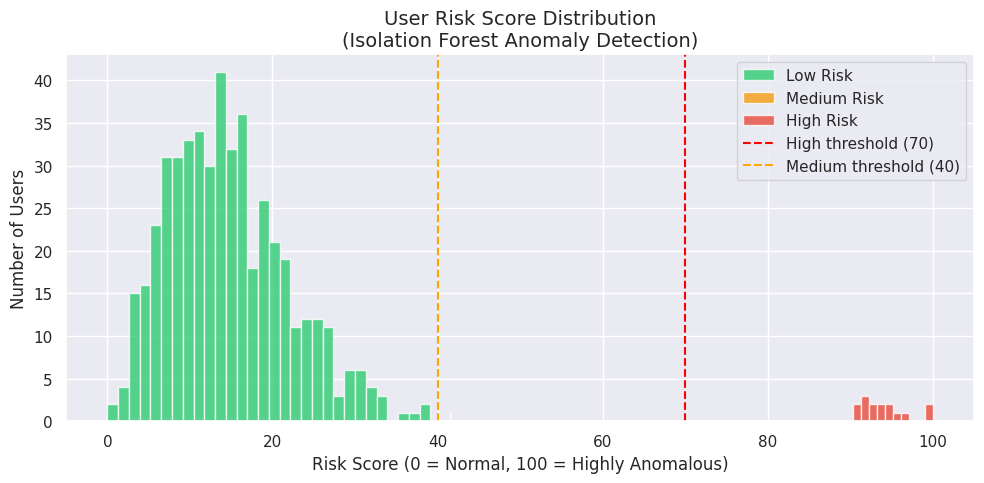

Chart 1 saved!


In [4]:
print("Generating risk score distribution...")

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df[df["risk_level"] == "Low"]["risk_score"],    bins=30,
        color=PALETTE["Low"],    alpha=0.8, label="Low Risk",    edgecolor="white")
ax.hist(df[df["risk_level"] == "Medium"]["risk_score"], bins=20,
        color=PALETTE["Medium"], alpha=0.8, label="Medium Risk", edgecolor="white")
ax.hist(df[df["risk_level"] == "High"]["risk_score"],   bins=10,
        color=PALETTE["High"],   alpha=0.8, label="High Risk",   edgecolor="white")

ax.axvline(70, color="red",    linestyle="--", linewidth=1.5, label="High threshold (70)")
ax.axvline(40, color="orange", linestyle="--", linewidth=1.5, label="Medium threshold (40)")

ax.set_xlabel("Risk Score (0 = Normal, 100 = Highly Anomalous)", fontsize=12)
ax.set_ylabel("Number of Users", fontsize=12)
ax.set_title("User Risk Score Distribution\n(Isolation Forest Anomaly Detection)", fontsize=14)
ax.legend()
fig.tight_layout()
fig.savefig(f"{CHART_DIR}/01_risk_distribution.png", dpi=150)
plt.show()
print("Chart 1 saved!")

Generating top 20 risk users chart...


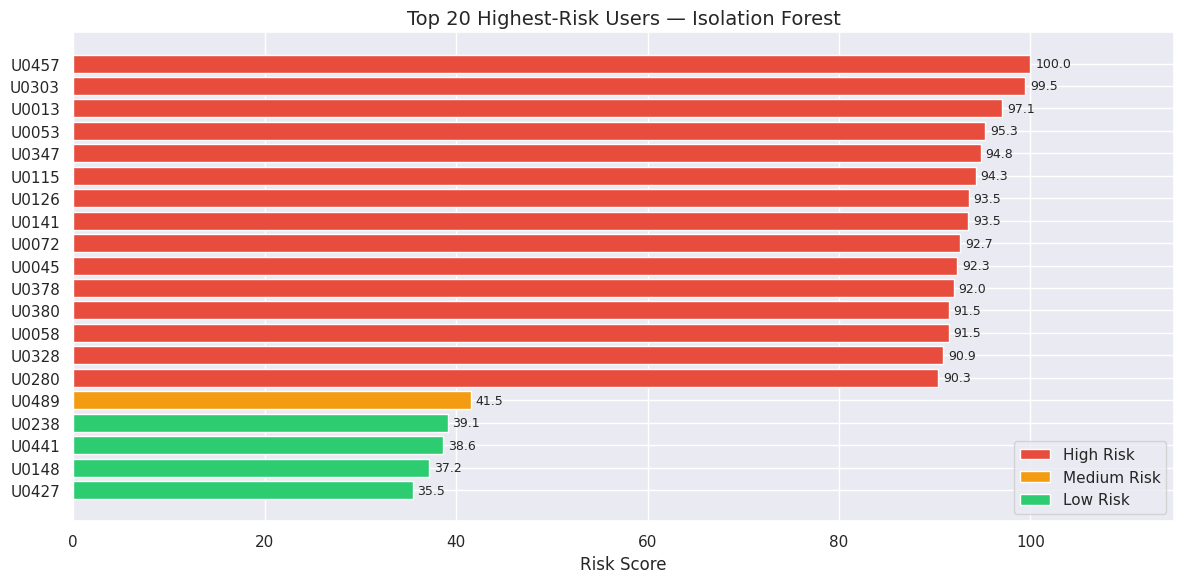

Chart 2 saved!


In [5]:
print("Generating top 20 risk users chart...")

top20 = df.head(20).copy()
bar_colors = top20["risk_level"].map(PALETTE)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top20["user"], top20["risk_score"], color=bar_colors, edgecolor="white")

for bar, score in zip(bars, top20["risk_score"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{score:.1f}", va="center", ha="left", fontsize=9)

ax.set_xlabel("Risk Score", fontsize=12)
ax.set_title("Top 20 Highest-Risk Users — Isolation Forest", fontsize=14)
ax.set_xlim(0, 115)
ax.invert_yaxis()

legend_elements = [Patch(facecolor=PALETTE["High"],   label="High Risk"),
                   Patch(facecolor=PALETTE["Medium"], label="Medium Risk"),
                   Patch(facecolor=PALETTE["Low"],    label="Low Risk")]
ax.legend(handles=legend_elements, loc="lower right")

fig.tight_layout()
fig.savefig(f"{CHART_DIR}/02_top20_users.png", dpi=150)
plt.show()
print("Chart 2 saved!")

Generating feature correlation heatmap...


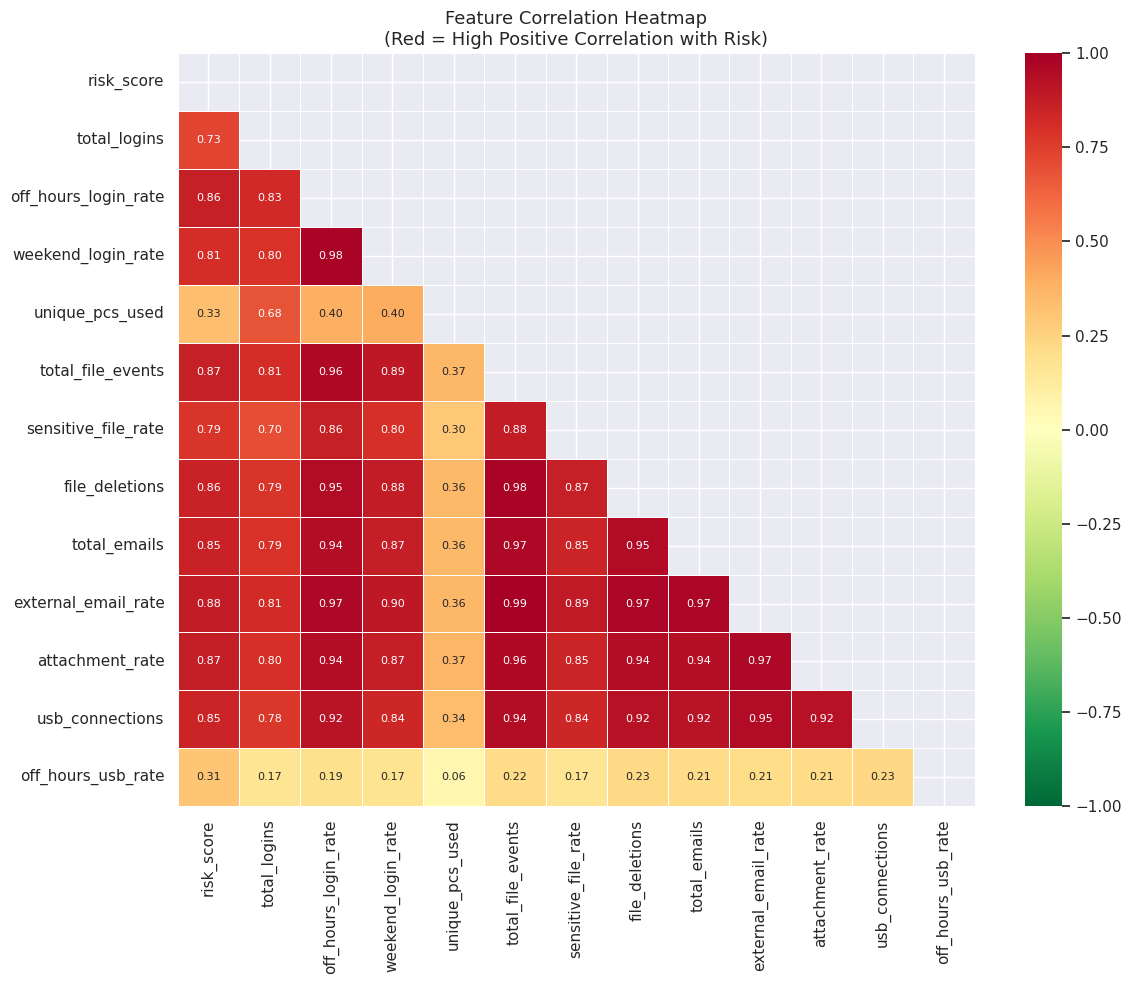

Chart 3 saved!


In [6]:
print("Generating feature correlation heatmap...")

heatmap_cols = [
    "risk_score", "total_logins", "off_hours_login_rate", "weekend_login_rate",
    "unique_pcs_used", "total_file_events", "sensitive_file_rate",
    "file_deletions", "total_emails", "external_email_rate",
    "attachment_rate", "usb_connections", "off_hours_usb_rate"
]
heatmap_cols = [c for c in heatmap_cols if c in df.columns]

corr = df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn_r",
            vmin=-1, vmax=1, center=0, ax=ax,
            annot_kws={"size": 8}, linewidths=0.5)
ax.set_title("Feature Correlation Heatmap\n(Red = High Positive Correlation with Risk)",
             fontsize=13)
fig.tight_layout()
fig.savefig(f"{CHART_DIR}/03_feature_heatmap.png", dpi=150)
plt.show()
print("Chart 3 saved!")

Generating off-hours box plot...


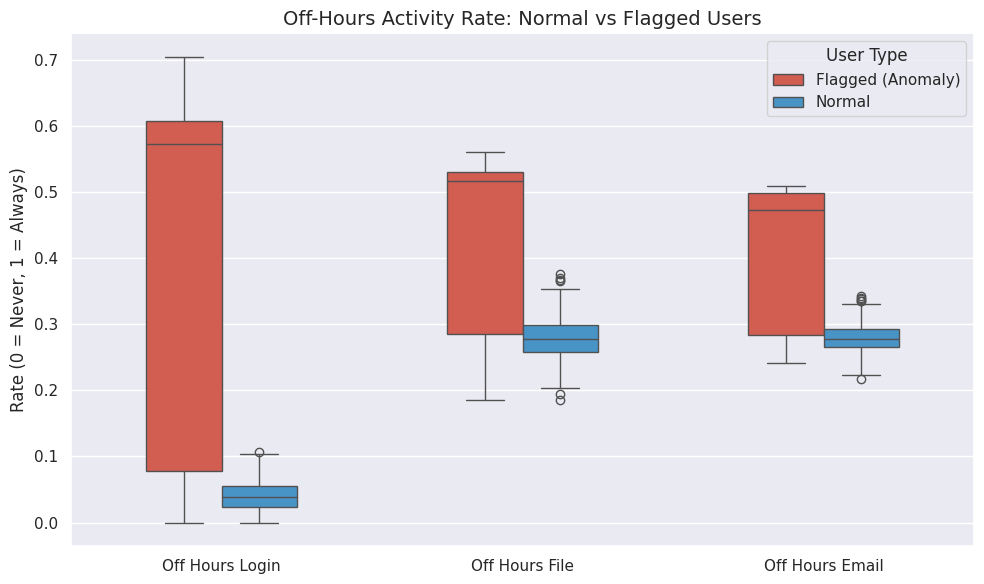

Chart 4 saved!


In [7]:
print("Generating off-hours box plot...")

plot_df = df[["is_anomaly", "off_hours_login_rate", "off_hours_file_rate",
              "off_hours_email_rate"]].copy()
plot_df["user_type"] = plot_df["is_anomaly"].map({True: "Flagged (Anomaly)",
                                                   False: "Normal"})

melted = plot_df.melt(id_vars="user_type",
                      value_vars=["off_hours_login_rate", "off_hours_file_rate",
                                  "off_hours_email_rate"],
                      var_name="Feature", value_name="Rate")
melted["Feature"] = melted["Feature"].str.replace("_rate", "").str.replace("_", " ").str.title()

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=melted, x="Feature", y="Rate", hue="user_type",
            palette={"Normal": "#3498db", "Flagged (Anomaly)": "#e74c3c"},
            ax=ax, width=0.5)
ax.set_ylabel("Rate (0 = Never, 1 = Always)", fontsize=12)
ax.set_xlabel("")
ax.set_title("Off-Hours Activity Rate: Normal vs Flagged Users", fontsize=14)
ax.legend(title="User Type")
fig.tight_layout()
fig.savefig(f"{CHART_DIR}/04_offhours_boxplot.png", dpi=150)
plt.show()
print("Chart 4 saved!")

Generating email vs USB scatter plot...


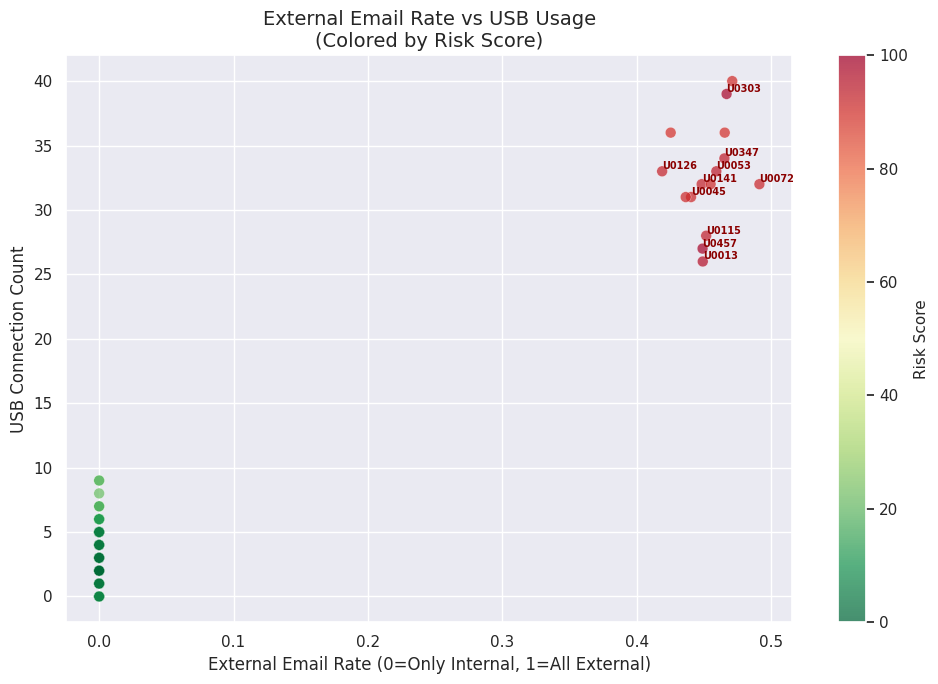

Chart 5 saved!


In [8]:
print("Generating email vs USB scatter plot...")

fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    df["external_email_rate"],
    df["usb_connections"],
    c=df["risk_score"],
    cmap="RdYlGn_r",
    alpha=0.7,
    s=60,
    edgecolors="white",
    linewidths=0.3,
    vmin=0, vmax=100
)

top10 = df.head(10)
for _, row in top10.iterrows():
    ax.annotate(row["user"],
                (row["external_email_rate"], row["usb_connections"]),
                fontsize=7, ha="left", va="bottom",
                color="darkred", fontweight="bold")

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Risk Score", fontsize=11)
ax.set_xlabel("External Email Rate (0=Only Internal, 1=All External)", fontsize=12)
ax.set_ylabel("USB Connection Count", fontsize=12)
ax.set_title("External Email Rate vs USB Usage\n(Colored by Risk Score)", fontsize=14)
fig.tight_layout()
fig.savefig(f"{CHART_DIR}/05_email_vs_usb.png", dpi=150)
plt.show()
print("Chart 5 saved!")

In [9]:
print("=" * 55)
print("  ALL 5 CHARTS GENERATED")
print("=" * 55)
print("  01_risk_distribution.png")
print("  02_top20_users.png")
print("  03_feature_heatmap.png")
print("  04_offhours_boxplot.png")
print("  05_email_vs_usb.png")
print("=" * 55)
print("All charts saved to Google Drive!")
print("Pipeline complete! 🎉")

  ALL 5 CHARTS GENERATED
  01_risk_distribution.png
  02_top20_users.png
  03_feature_heatmap.png
  04_offhours_boxplot.png
  05_email_vs_usb.png
All charts saved to Google Drive!
Pipeline complete! 🎉
